In [1]:
#Add path to recording here
Recordings = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\022024\G6CK10DTT']


In [2]:
##Defining kde_PSTH function

def calc_kde_PSTH(spikeT, eventT, bandwidth=10, resample_size=1,
                      edgedrop=15, win=1000):
        """Calculate PSTH for a single unit.

        The Peri-Stimulus Time Histogram (PSTH) will be calculated using Kernel
        Density Estimation by sliding a gaussian along the spike times centered
        on the event time.

        Because the gaussian filter will create artifacts at the edges (i.e. the
        start and end of the time window), it's best to add extra time to the start
        and end and then drop that time from the PSTH, leaving the final PSTH with no
        artifacts at the start and end. The time (in msec) set with `edgedrop` pads
        the start and end with some time which is dropped from the final PSTH before
        the PSTH is returned.

        Parameters
        ----------
        spikeT : np.array
            Array of spike times in seconds and with the type float. Should be 1D and be
            the spike times for a single ephys unit.
        eventT : np.array
            Array of event times (e.g. presentation of stimulus or the time of a saccade)
            in seconds and with the type float.
        bandwidth : int
            Bandwidth of KDE filter in units of milliseconds.
        resample_size : int
            Size of binning when resampling spike rate, in units of milliseconds.
        edgedrop : int
            Time to pad at the start and end, and then dropped, to eliminate edge artifacts.
        win : int
            Window in time to use in positive and negative directions. For win=1000, the
            PSTH will start -1000 ms before the event and end +1000 ms after the event.

        Returns
        -------
        psth : np.array
            Peri-Stimulus Time Histogram

        """

        # Unit conversions
        bandwidth = bandwidth / 1000
        resample_size = resample_size / 1000
        win = win / 1000
        edgedrop = edgedrop / 1000
        edgedrop_ind = int(edgedrop / resample_size)

        bins = np.arange(-win-edgedrop, win+edgedrop+resample_size, resample_size)

        # Timestamps of spikes (`sps`) relative to `eventT`
        sps = []
        for i, t in enumerate(eventT):
            sp = spikeT-t
            # Only keep spikes in this window
            sp = sp[(sp <= (win+edgedrop)) & (sp >= (-win-edgedrop))] 
            sps.extend(sp)
        sps = np.array(sps)

        if len(sps) < 10:
            n_bins = int((win * 1000 * 2) + 1)
            return np.zeros(n_bins)*np.nan

        kernel = sklearn.neighbors.KernelDensity(kernel='gaussian',
                                                 bandwidth=bandwidth).fit(sps[:, np.newaxis])
        density = kernel.score_samples(bins[:, np.newaxis])

        # Multiply by the # spikes to get spike count per point. Divide
        # by # events for rate/event.
        psth = np.exp(density) * (np.size(sps ) / np.size(eventT))

        # Drop padding at start & end to eliminate edge effects.
        psth = psth[edgedrop_ind:-edgedrop_ind]

        return psth

##Defining STD Plot function
def plot_group_mean_std(group_mean, group_std, color, label):
    plt.plot(group_mean, c=color, label=label, linewidth=3)
    plt.fill_between(range(len(group_mean)), group_mean - group_std, group_mean + group_std, color=color, alpha=0.1)
    plt.legend()



In [4]:
import os
import cv2
import sys
import math
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import scipy.interpolate
import scipy.signal
import sklearn.cluster
import fmEphys as fme

import sys
sys.path.append(r"C:\Users\Niell Lab\Documents\GitHub\freely-moving-saccades")
import saccadeAnalysis as sacc

###############################################################################################################
for RecordingPath in Recordings:
    #Finding grating ephys and world cam files as well as freely moving ephys files 
    print('loading grating data and world cam footage and single unit file')

    Grating_Files  = []
    Grating_WorldVid = []
    FM_Files = []

    for folders in os.listdir(RecordingPath):

        if folders.endswith("gratings"):
            for grating_subfolder in os.listdir(RecordingPath +'/' + folders):
                if grating_subfolder.endswith("ephys_props.h5"):
                    Grating_Files.append(RecordingPath + '/' + folders + '/' + grating_subfolder)
                if grating_subfolder.endswith("WORLDdeinter.avi"):
                    Grating_WorldVid.append(RecordingPath + '/' + folders + '/' + grating_subfolder)

        if folders.endswith("fm1"):
            for fm1_subfolder in os.listdir(RecordingPath +'/'+folders):
                if fm1_subfolder.endswith("ephys_props.h5"):
                    FM_Files.append(RecordingPath + '/' + folders + '/' + fm1_subfolder)
                    
        if folders.endswith("fm2"):
            for fm1_subfolder in os.listdir(RecordingPath +'/'+folders):
                if fm1_subfolder.endswith("ephys_props.h5"):
                    FM_Files.append(RecordingPath + '/' + folders + '/' + fm1_subfolder)
                    
    PreDOI_GratingData = pd.read_hdf(Grating_Files[0])
    PostDOI_GratingData = pd.read_hdf(Grating_Files[1])

    PreDOI_FMData = pd.read_hdf(FM_Files[0])
    PostDOI_FMData = pd.read_hdf(FM_Files[1])

    ###############################################################################################################

    # Single Unit Indexes from Step 1

    Items = os.listdir(RecordingPath)
    for names in Items:
        if names.endswith("SingleUnits_NoThresh.npy"):
            SingleUnits_File = RecordingPath + '/' + names

    Single_Units = np.load(SingleUnits_File)

    ###############################################################################################################
    ##Calculating the Grating Stimulus from the World camera footage
    print('Calculating the Grating Stimulus from the World camera footage')

    ds = .25

    tf_cat = np.zeros(len(Grating_WorldVid),object)
    sf_cat = np.zeros(len(Grating_WorldVid),object)
    ori_cat = np.zeros(len(Grating_WorldVid),object)

    ntrial = np.zeros((3,8,len(Grating_WorldVid)))

    for condition in tqdm(range(len(Grating_WorldVid))):
        vid = cv2.VideoCapture(Grating_WorldVid[condition]) #filepath & name of the video
                                

        # array to put video frames into
        # will have the shape: [frames, height, width] and be returned with dtype=int8
        img_ds = np.empty([int(vid.get(cv2.CAP_PROP_FRAME_COUNT)),
                            int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT)*ds),
                            int(vid.get(cv2.CAP_PROP_FRAME_WIDTH)*ds)], dtype=np.uint8)
        # iterate through each frame
        for f in range(0,int(vid.get(cv2.CAP_PROP_FRAME_COUNT))):
            # read the frame in and make sure it is read in correctly
            ret, img = vid.read()
            if not ret:
                break
            # convert to grayscale
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # downsample the frame by an amount specified in the config file
            img_s = cv2.resize(img, (0,0), fx=ds, fy=ds, interpolation=cv2.INTER_NEAREST)
            # add the downsampled frame to all_frames as int8
            img_ds[f,:,:] = img_s.astype(np.int8)


        #calc std of video
        std_im = np.std(img_ds, axis=0)

        #normalize video
        img_norm = (img_ds - np.mean(img_ds, axis=0))/std_im

        #drop static world cam  pixels
        std_im[std_im <20] = 0 
        img_norm = img_norm * (std_im>0)

        # Pixel range to define screen
        xrg=40
        yrg=25

        # Initialize arrays for stimulus data
        nf = np.size(img_norm, 0) - 1

        u_mn = np.zeros((nf, 1))
        v_mn = np.zeros((nf, 1))

        sx_mn = np.zeros((nf, 1))
        sy_mn = np.zeros((nf, 1))

        flow_norm = np.zeros((nf,
                                np.size(img_norm,1),
                                np.size(img_norm,2),
                                2))



        # Find screen
        meanx = np.mean(std_im > 0, axis=0)
        xcent = np.int_(np.sum(meanx * np.arange(len(meanx))) / np.sum(meanx))

        meany = np.mean(std_im > 0, axis=1)
        ycent = np.int_(np.sum(meany * np.arange(len(meany))) / np.sum(meany))


        # Optic flow
        #fig, ax = plt.subplots(1, 1, figsize=(16,8))

        for f in tqdm(range(nf)):

                # two frames to compare when calculating optic flow
                frm = np.uint8(32*(img_norm[f,:,:]+4))
                frm2 = np.uint8(32*(img_norm[f+1,:,:]+4))

                flow_norm[f,:,:,:] = cv2.calcOpticalFlowFarneback(
                                            frm,  # current frame
                                            frm2, # next frame
                                            None, # no preexisting flow data
                                            0.5,  # pyramid image scale
                                            3,    # number of pyramid levels
                                            30,   # window size
                                            3,    # num iterations
                                            7,    # pixel neighborhood size
                                            1.5,  # gaussian std
                                            0)     # flags
                
                # Flow vectors
                u = flow_norm[f,:,:,0]

                # Vector v has negative to fix sign for y axis
                # in images (same is done for sy below)
                v = -flow_norm[f,:,:,1]

                sx = cv2.Sobel(frm, cv2.CV_64F, 1, 0, ksize=11)

                sy = -cv2.Sobel(frm, cv2.CV_64F, 0, 1, ksize=11)

                # Get rid of values outside of monitor
                sx[std_im < 20] = 0
                sy[std_im < 20] = 0


                # Make vectors point in positive x direction
                # so opposite sides of grating don't cancel
                sy[sx < 0] = -sy[sx < 0] 
                sx[sx < 0] = -sx[sx < 0]

                sy[np.abs(sx/sy) < 0.15] = np.abs(sy[np.abs(sx/sy) < 0.15])

                u_mn[f] = np.mean(u[ycent-yrg:ycent+yrg,
                                    xcent-xrg:xcent+xrg])
                
                v_mn[f]= np.mean(v[ycent-yrg:ycent+yrg,
                                    xcent-xrg:xcent+xrg])
                
                sx_mn[f] = np.mean(sx[ycent-yrg:ycent+yrg,
                                        xcent-xrg:xcent+xrg])
                
                sy_mn[f] = np.mean(sy[ycent-yrg:ycent+yrg,
                                        xcent-xrg:xcent+xrg])


        scr_contrast = np.empty(img_norm.shape[0])

        for i in range(img_norm.shape[0]):
            scr_contrast[i] = np.nanmean(np.abs(img_norm[i,
                                                                    ycent-yrg:ycent+yrg,
                                                                    xcent-xrg:xcent+xrg]))
            
        scr_contrast = scipy.signal.medfilt(scr_contrast, 11)

        stimOn = np.double(scr_contrast > 0.5)

        worldT = np.array(range(0,img_norm.shape[0]))

        stim_start = np.array(worldT[np.where(np.diff(stimOn) > 0)])

        # Shift everything forward so that t=0 is centered
        # between frame 0 and frame 1
        stim_onsets_ = stim_start.copy()

        stim_end = np.array(worldT[np.where(np.diff(stimOn) < 0)])
        stim_end = stim_end[stim_end > stim_start[0]]

        stim_start = stim_start[stim_start < stim_end[-1]]

        grating_th = np.zeros(len(stim_start))
        grating_mag = np.zeros(len(stim_start))
        grating_dir = np.zeros(len(stim_start))
        dI = np.zeros(len(stim_start))


        for i in range(len(stim_start)):
            
            if i >= len(stim_start):
                continue

            tpts = np.where((worldT > stim_start[i] + 0.025)
                            & (worldT < stim_end[i] - 0.025))
            
            if np.size(tpts)==0:
                
                # if a spurious stimulus start, with no presented frames in the worldcam video, was
                # included as a stim presentation, throw it out and shorten the returned arrays by one
                # stimulus event

                grating_th = grating_th[:-1]
                grating_mag = grating_mag[:-1]
                grating_dir = grating_dir[:-1]
                dI = dI[:-1]

                stim_start = np.delete(stim_start, obj=i, axis=0)
                continue

            
            mag = np.sqrt(sx_mn[tpts]**2 + sy_mn[tpts]**2)

            this = np.where(mag[:,0] > np.percentile(mag,25))

            goodpts = np.array(tpts)[0,this]

            stim_sx = np.nanmedian(sx_mn[tpts])
            stim_sy = np.nanmedian(sy_mn[tpts])
            stim_u = np.nanmedian(u_mn[tpts])
            stim_v = np.nanmedian(v_mn[tpts])

            grating_th[i] = np.arctan2(stim_sy, stim_sx)
            grating_mag[i] = np.sqrt(stim_sx**2 + stim_sy**2)

            # Dot product of gratient and flow gives direction
            grating_dir[i] = np.sign(stim_u*stim_sx + stim_v*stim_sy)

            # Rate of change of image give temporal frequency
            dI[i] = np.mean(np.diff(img_norm[tpts, ycent, xcent])**2)
                        
        #Calculating Grating Ori
        grating_ori = grating_th
        grating_ori[grating_dir < 0] = grating_ori[grating_dir < 0] + np.pi
        grating_ori = grating_ori - np.min(grating_ori)

        # Category of orientations
        ori_cat[condition] = np.floor((grating_ori+np.pi/16) / (np.pi/4))

        # Temporal frequencies: 0=low, 1=high
        tf_cat[condition] = np.zeros(len(dI))
        tf_cat[condition][dI > 0.5] = 1

        # Cluster spatial frequencies
        km = sklearn.cluster.KMeans(n_clusters=3).fit(np.reshape(grating_mag, (-1,1)))
        sf_cat[condition] = km.labels_

        order = np.argsort(np.reshape(km.cluster_centers_, 3))

        sf_catnew = sf_cat[condition].copy()

        for i in range(3):
            sf_catnew[sf_cat[condition] == order[i]] = i

        sf_cat[condition] = sf_catnew.copy()

        for i in range(3):
            for j in range(8):
                ntrial[i, j, condition] = np.sum((sf_cat[condition]==i) & (ori_cat[condition]==j))

    ###############################################################################################################
    #Calculating Spikes Times for Raster Plots
    print('Calculating Raster Plot Data')

    Pre_stimT = PreDOI_GratingData['Gt_stimT'] 
    Pre_spikeT = PreDOI_GratingData['Gt_spikeT']

    Post_stimT = PostDOI_GratingData['Gt_stimT'] 
    Post_spikeT = PostDOI_GratingData['Gt_spikeT']


    SpikeRasters = np.empty([np.size(Single_Units),2,3,8,2],object)
    #Post_SpikeRasters = np.empty([np.size(Single_Units),2,3,8],object)

    for ii in tqdm(list(range(len(Single_Units)))):
        cluster = Single_Units[ii]



        for tf in range(2):   #looping through gratings (tf)
            for sf in range(3):   #looping through gratings (sf)
                for ori in range(8):   #looping through gratings (ori)
                    
                    StimT_Pre = Pre_stimT[cluster][np.argwhere((tf_cat[0][:-1] == tf) & (sf_cat[0][:-1] == sf) & (ori_cat[0][:-1] == ori))]          #Finding Specific Stim Times
                    temp = np.empty(len(StimT_Pre),object)
                    for reps in range(len(StimT_Pre)):
                        temp[reps] =  Pre_spikeT[cluster][np.argwhere((Pre_spikeT[cluster]  >= StimT_Pre[reps]-1.5) & (Pre_spikeT[cluster]   <= StimT_Pre[reps]+1.5))]-StimT_Pre[reps]
                    SpikeRasters[ii,tf,sf,ori,0] = temp

                    StimT_Post = Post_stimT[cluster][np.argwhere((tf_cat[1][:-1] == tf) & (sf_cat[1][:-1] == sf) & (ori_cat[1][:-1] == ori))]          #Finding Specific Stim Times
                    temp = np.empty(len(StimT_Post),object)
                    for reps in range(len(StimT_Post)):
                        temp[reps] =  Post_spikeT[cluster][np.argwhere((Post_spikeT[cluster]  >= StimT_Post[reps]-1.5) & (Post_spikeT[cluster]  <= StimT_Post[reps]+1.5))]-StimT_Post[reps]
                    SpikeRasters[ii,tf,sf,ori,1] = temp


    ###############################################################################################################
    #Calculating PSTH via kde for pre and post doi
    print('Calculating PSTH Data for Gratings')

    PSTH_Pre_temp = np.zeros([np.size(Single_Units),2,3,8,3001])
    PSTH_Pre = np.zeros([np.size(Single_Units),2,3,8,3001])
    #PSTH_Pre_Norm = np.zeros([np.size(Single_Units),2,3,8,3001])
    Mx_Pre = np.zeros([np.size(Single_Units)])
    Mx_Idx_Pre = np.zeros([np.size(Single_Units),4])
    AvPSTH_Pre = np.zeros([np.size(Single_Units),3001])*np.nan
    AvPSTH_Norm_Pre = np.zeros([np.size(Single_Units),3001])*np.nan
    raw_mod_Pre = np.zeros([np.size(Single_Units)])
    norm_mod_Pre = np.zeros([np.size(Single_Units)])
    Responsive_Pre = np.zeros([np.size(Single_Units)])


    PSTH_Post_temp = np.zeros([np.size(Single_Units),2,3,8,3001])
    PSTH_Post = np.zeros([np.size(Single_Units),2,3,8,3001])
    #PSTH_Post_Norm = np.zeros([np.size(Single_Units),2,3,8,3001])
    Mx_Post = np.zeros([np.size(Single_Units)])
    Mx_Idx_Post = np.zeros([np.size(Single_Units),4])
    AvPSTH_Post = np.zeros([np.size(Single_Units),3001])*np.nan
    AvPSTH_Norm_Post = np.zeros([np.size(Single_Units),3001])*np.nan
    raw_mod_Post = np.zeros([np.size(Single_Units)])
    norm_mod_Post = np.zeros([np.size(Single_Units)])
    Responsive_Post = np.zeros([np.size(Single_Units)])

    AllGrating_PSTH_Pre = np.zeros([np.size(Single_Units),3001])*np.nan

    for ii in tqdm(list(range(len(Single_Units)))):

        cluster = Single_Units[ii]

        

        #Caculating the PSTH to all gratings before and after DOI
        AvPSTH_Pre[ii,:] = calc_kde_PSTH(Pre_spikeT[cluster],Pre_stimT[cluster],bandwidth=10,resample_size=1,edgedrop=30,win=1500) #Calculate PSTH
        AvPSTH_Norm_Pre[ii,:] = sacc.norm_PSTH(AvPSTH_Pre[ii,:], trange='gt')  #normalized PSTH
        raw_mod_Pre[ii] = sacc.calc_PSTH_modind(AvPSTH_Pre[ii,:], trange='gt')  
        norm_mod_Pre[ii] = sacc.calc_PSTH_modind(AvPSTH_Norm_Pre[ii,:], trange='gt')
        
        if (raw_mod_Pre[ii] > 1) and (norm_mod_Pre[ii]>.1):
            Responsive_Pre[ii] = 1


        AvPSTH_Post[ii,:] = calc_kde_PSTH(Post_spikeT[cluster],Post_stimT[cluster],bandwidth=10,resample_size=1,edgedrop=30,win=1500) #Calculate PSTH
        AvPSTH_Norm_Post[ii,:] = sacc.norm_PSTH(AvPSTH_Post[ii,:], trange='gt')  #normalized PSTH
        raw_mod_Post[ii] = sacc.calc_PSTH_modind(AvPSTH_Post[ii,:], trange='gt')  
        norm_mod_Post[ii] = sacc.calc_PSTH_modind(AvPSTH_Norm_Post[ii,:], trange='gt')
        
        if (raw_mod_Post[ii] > 1) and (norm_mod_Post[ii]>.1):
            Responsive_Post[ii] = 1  



        for tf in range(2):   #looping through gratings (tf)
            for sf in range(3):   #looping through gratings (sf)
                for ori in range(8):   #looping through gratings (ori)
                    
                    # Pre DOI
                    StimT_Pre = Pre_stimT[cluster][np.argwhere((tf_cat[0][:-1] == tf) & (sf_cat[0][:-1] == sf) & (ori_cat[0][:-1] == ori))]          #Finding Specific Stim Times
                    PSTH_Pre[ii,tf,sf,ori,:] = calc_kde_PSTH(Pre_spikeT[cluster],StimT_Pre,bandwidth=10, resample_size=1, edgedrop=30, win=1500)   #calculating PSTH via KDE method
                    PSTH_Pre_temp[ii,tf,sf,ori,:] = PSTH_Pre[ii,tf,sf,ori,:].copy()
                    PSTH_Pre[ii,tf,sf,ori,:] = PSTH_Pre[ii,tf,sf,ori,:] - np.nanmean(PSTH_Pre[ii,tf,sf,ori,1100:1400])    #Subtracting off baseline from PSTH
                    

                    #Post DOI
                    StimT_Post = Post_stimT[cluster][np.argwhere((tf_cat[1][:-1] == tf) & (sf_cat[1][:-1] == sf) & (ori_cat[1][:-1] == ori))]          #Finding Specific Stim Times
                    PSTH_Post[ii,tf,sf,ori,:] = calc_kde_PSTH(Post_spikeT[cluster],StimT_Post,bandwidth=10, resample_size=1, edgedrop=30, win=1500)   #calculating PSTH via KDE method
                    PSTH_Post_temp[ii,tf,sf,ori,:] = PSTH_Post[ii,tf,sf,ori,:].copy()
                    PSTH_Post[ii,tf,sf,ori,:] = PSTH_Post[ii,tf,sf,ori,:] - np.nanmean(PSTH_Post[ii,tf,sf,ori,1100:1400])      #Subtracting off baseline from PSTH
                    

    ##Normalizing to Max for Average Response
    Mx = np.nanmax([np.nanmax(np.abs(AvPSTH_Pre[:,1500:2500]),axis=1),np.nanmax(np.abs(AvPSTH_Post[:,1500:2500]),axis=1)],axis=0)

    AvPSTH_Norm_Pre = AvPSTH_Pre/Mx[:,None]
    AvPSTH_Norm_Post = AvPSTH_Post/Mx[:,None]

    del Mx

    #Normalizing to Max Modulation (take absolute value of each response before finding max to account for SBC cells) for Each Individual Response
    Mx = [np.nanmax(np.nanmax(np.nanmax(np.nanmax(PSTH_Pre_temp[:,:,:,:,1500:2500],axis=4),axis=3),axis=2),axis=1), np.nanmax(np.nanmax(np.nanmax(np.nanmax(PSTH_Post_temp[:,:,:,:,1500:2500],axis=4),axis=3),axis=2),axis=1)]
    Mx = np.nanmax(Mx,axis=0)

    PSTH_Norm_Pre = PSTH_Pre/Mx[:,None,None,None,None]
    PSTH_Norm_Post= PSTH_Post/Mx[:,None,None,None,None]

    del Mx

    ###############################################################################################################
    #Calculating tuning metrics and grating preferences
    print('Calculating Ori, SF and TF Tuning Metrics')

    Pref_Norm_PSTH_Pre = np.zeros([np.size(Single_Units),3001])*np.nan
    Pref_Norm_PSTH_Post = np.zeros([np.size(Single_Units),3001])*np.nan

    Pref_Idx = np.zeros([np.size(Single_Units),4,2])*np.nan

    Tuning = np.zeros([np.size(Single_Units),2,3,8,2])*np.nan

    gDSI = np.empty([np.size(Single_Units),2,3,2])*np.nan
    WeightedSF = np.empty([np.size(Single_Units),2,8,2])*np.nan
    WeightedTF = np.empty([np.size(Single_Units),3,8,2])*np.nan
    OctShiftSF = np.empty([np.size(Single_Units),2,8])*np.nan

    tt = 0
    zz = 0

    for ii in tqdm(list(range(len(Single_Units)))):

        for tf in range(2):   #looping through gratings (tf)
            for sf in range(3):   #looping through gratings (sf)
                for ori in range(8):   #looping through gratings (ori)
                    
                    #Finding Tuning of each Grating as average response 25ms to 1000ms after onset minus average baseline of respoonse from 500ms before response - baseline subtraction done above
                    Tuning[ii,tf,sf,ori,0] = np.nanmean(PSTH_Pre[ii,tf,sf,ori,1525:2500])
                    Tuning[ii,tf,sf,ori,1] = np.nanmean(PSTH_Post[ii,tf,sf,ori,1525:2500])
                    
                    #Making negative tuning responses equal to 0 
                    Tuning[Tuning<0] = 0
                    Tuning[np.isnan(Tuning)] = 0

                    #Calculating Weighted Spatial Frequency Preference at each combo of TF and Ori
                    WeightedSF[ii,tf,ori,0] = ((Tuning[ii,tf,0,ori,0]*1)+(Tuning[ii,tf,1,ori,0]*2)+(Tuning[ii,tf,2,ori,0]*3))/np.sum(Tuning[ii,tf,:,ori,0])
                    WeightedSF[ii,tf,ori,1] = ((Tuning[ii,tf,0,ori,1]*1)+(Tuning[ii,tf,1,ori,1]*2)+(Tuning[ii,tf,2,ori,1]*3))/np.sum(Tuning[ii,tf,:,ori,1])

                    #Calculating Weighted Temporal Frequency Preference at each combo of SF and Ori
                    WeightedTF[ii,sf,ori,0] = ((Tuning[ii,0,sf,ori,0]*1)+(Tuning[ii,1,sf,ori,0]*2))/np.sum(Tuning[ii,:,sf,ori,0])
                    WeightedTF[ii,sf,ori,1] = ((Tuning[ii,0,sf,ori,1]*1)+(Tuning[ii,1,sf,ori,1]*2))/np.sum(Tuning[ii,:,sf,ori,1])
                        
                #Calculating global Direction Selectivity Index for each combo of tf and sf
                gDSI[ii,tf,sf,0] = 1 - (np.ptp(Tuning[ii,tf,sf,:,0])/sum(Tuning[ii,tf,sf,:,0]))
                gDSI[ii,tf,sf,1] = 1 - (np.ptp(Tuning[ii,tf,sf,:,1])/sum(Tuning[ii,tf,sf,:,1]))

        #Calcuating the change in SF Preference in Octaves for each TF, Ori combo such that postive numbers represent higher SF preferences after DOI and negative numbers represent lower SF preferences after DOI
        OctShiftSF[ii] = np.log2(WeightedSF[ii,:,:,1]) - np.log2(WeightedSF[ii,:,:,0])

        #Finding Grating that evoked the largest response (max method)
        tempPre = np.argwhere(PSTH_Norm_Pre[ii,:,:,:,1500:3000] == np.nanmax(PSTH_Norm_Pre[ii,:,:,:,1500:3000]))
        if len(tempPre) == 0:
            Pref_Idx[ii,:,0] = np.nan
        else:
            Pref_Idx[ii,:,0] = [tempPre[0][0],tempPre[0][1],tempPre[0][2],tempPre[0][3]]
    



    
        tempPost = np.argwhere(PSTH_Norm_Post[ii,:,:,:,1500:3000] == np.nanmax(PSTH_Norm_Post[ii,:,:,:,1500:3000]))
        if len(tempPost) == 0:
            Pref_Idx[ii,0,1] = np.nan
        else:
            Pref_Idx[ii,:,1] = [tempPost[0][0],tempPost[0][1],tempPost[0][2],tempPost[0][3]]
    
        #Pulling the preferred response and adding it to a new variable
        if np.sum(np.isnan(Pref_Idx[ii,:,0])) > 0:
            Pref_Norm_PSTH_Pre[ii,:] = 'NaN'
            tt = tt+1
        else:
            Pref_Norm_PSTH_Pre[ii,:] = PSTH_Norm_Pre[ii,int(Pref_Idx[ii,0,0]),int(Pref_Idx[ii,1,0]),int(Pref_Idx[ii,2,0]),:]
        
        if np.sum(np.isnan(Pref_Idx[ii,:,1])) > 0:
            Pref_Norm_PSTH_Post[ii,:] = 'NaN'
            zz = zz+1 
        else:
            Pref_Norm_PSTH_Post[ii,:] = PSTH_Norm_Post[ii,int(Pref_Idx[ii,0,1]),int(Pref_Idx[ii,1,1]),int(Pref_Idx[ii,2,1]),:]
            

    data = []

    print('Saving Grating Data into Mouse Folder')

    for ii in tqdm(list(range(len(Single_Units)))):
        Cell = Single_Units[ii]
        data.append({'Cell': Single_Units[ii], 
                    'Ori_Seq': ori_cat, 
                    'SF_Seq': sf_cat,
                    'TF_Seq': tf_cat,
                    'SpikeRaster': SpikeRasters[ii,:,:,:,:],
                    'PSTH_Pre': PSTH_Pre[ii,:,:,:,:],
                    'PSTH_Norm_Pre': PSTH_Norm_Pre[ii,:,:,:,:],
                    'Av_PSTH_Pre': AvPSTH_Pre[ii,:],
                    'Av_PSTH_Norm_Pre': AvPSTH_Norm_Pre[ii,:],
                    'Pref_Norm_PSTH_Pre': Pref_Norm_PSTH_Pre[ii,:],
                    'PSTH_Post': PSTH_Post[ii,:,:,:,:],
                    'PSTH_Norm_Post': PSTH_Norm_Post[ii,:,:,:,:],
                    'Av_PSTH_Post': AvPSTH_Post[ii,:],
                    'Av_PSTH_Norm_Post': AvPSTH_Norm_Post[ii,:],
                    'Pref_Norm_PSTH_Post': Pref_Norm_PSTH_Post[ii,:],
                    'Pref_Idx': Pref_Idx[ii,:,:],
                    'gDSI': gDSI[ii,:,:,:],
                    'WeightedSF': WeightedSF[ii,:,:,:],
                    'OctShift': OctShiftSF[ii,:,:],
                    'WeightedTF': WeightedTF[ii,:,:,:],
                    'Tuning': Tuning[ii,:,:,:,:],
                    'Responsive_Pre': Responsive_Pre[ii],
                    'Responsive_Post': Responsive_Post[ii]})

    GratingData= pd.DataFrame(data)

    GratingData.to_hdf(os.path.join(os.path.join(RecordingPath,'grating_data.h5')), 'w')
print('Done!')

loading grating data and world cam footage and single unit file
Calculating the Grating Stimulus from the World camera footage


100%|██████████| 2/2 [13:56<00:00, 418.28s/it]


Calculating Raster Plot Data


100%|██████████| 106/106 [00:05<00:00, 18.87it/s]


Calculating PSTH Data for Gratings


...

Calculating Ori, SF and TF Tuning Metrics


100%|██████████| 106/106 [00:00<00:00, 106.64it/s]


Saving Grating Data into Mouse Folder


100%|██████████| 106/106 [00:00<00:00, 106184.91it/s]


NoSuchNodeError: group ``/w`` does not have a child named ``block1_values``

In [7]:
GratingData.to_hdf(os.path.join(os.path.join('D:\PrePostDOI','grating_data.h5')), 'w')

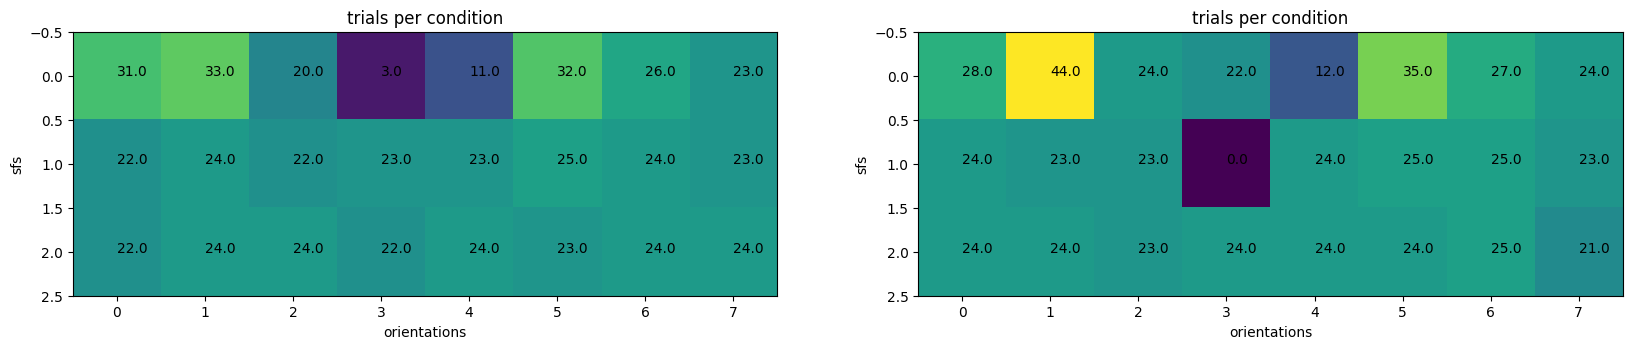

In [7]:
fig, axs = plt.subplots(1,len(Grating_WorldVid), figsize = [20,8])
for condition in range(len(Grating_WorldVid)):
    axs[condition].imshow(ntrial[:,:,condition], vmin=0, vmax=np.max(ntrial))  
    for sf in range(3):
        for ori in range(8):
            axs[condition].text(ori,sf,ntrial[sf,ori,condition])
    axs[condition].set_xlabel('orientations')
    axs[condition].set_ylabel('sfs')
    axs[condition].set_title('trials per condition')

In [13]:
column_names = list(GratingData.columns.values)
print(column_names)

['Cell', 'Ori_Seq', 'SF_Seq', 'TF_Seq', 'SpikeRaster', 'PSTH_Pre', 'PSTH_Norm_Pre', 'Av_PSTH_Pre', 'Pref_Norm_PSTH_Pre', 'PSTH_Post', 'PSTH_Norm_Post', 'Av_PSTH_Post', 'Pref_Norm_PSTH_Post', 'Pref_Idx', 'gDSI', 'WeightedSF', 'OctShift', 'WeightedTF', 'Tuning']


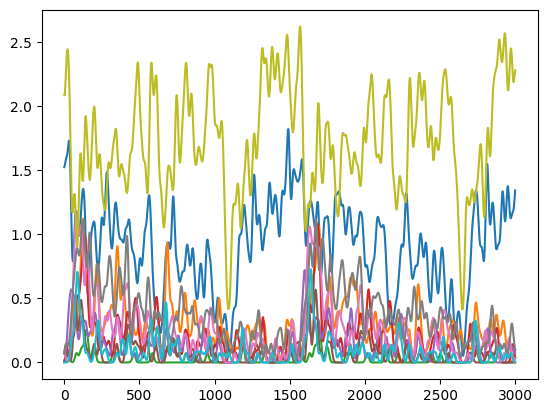

In [27]:
plt.plot(np.stack(GratingData.loc[Responsive_Pre == 0,'Av_PSTH_Pre']).T)

In [23]:
sum(Responsive_Pre)/len(Responsive_Pre)

0.8484848484848485

In [24]:
sum(Responsive_Post)/len(Responsive_Post)

0.803030303030303

In [25]:
Responsive_Pre == 1

array([ True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True, False,  True,  True,  True,
       False,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True, False,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True, False,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])